
**Name:** Manmath Kornule

**Prn**: 202401110045

---

# **1. Objective:**  
**To implement and evaluate a Logistic Regression model to detect the malware.**

---

Dataset Link(Kaggle) : https://www.kaggle.com/datasets/nsaravana/malware-detection

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("Malware dataset.csv")

In [3]:
df.head()

,hash,millisecond,classification,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,...,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
0,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,0.0,malware,0.0,0.0,3.069379e+09,14274.0,0.0,0.0,0.0,...,0.0,0.0,120.0,0.0,3.204448e+09,380690.0,4.0,0.0,0.0,0.0
1,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,1.0,malware,0.0,0.0,3.069379e+09,14274.0,0.0,0.0,0.0,...,0.0,0.0,120.0,0.0,3.204448e+09,380690.0,4.0,0.0,0.0,0.0
2,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,2.0,malware,0.0,0.0,3.069379e+09,14274.0,0.0,0.0,0.0,...,0.0,0.0,120.0,0.0,3.204448e+09,380690.0,4.0,0.0,0.0,0.0
3,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,3.0,malware,0.0,0.0,3.069379e+09,14274.0,0.0,0.0,0.0,...,0.0,0.0,120.0,0.0,3.204448e+09,380690.0,4.0,0.0,0.0,0.0
4,42fb5e2ec009a05ff5143227297074f1e9c6c3ebb9c914...,4.0,malware,0.0,0.0,3.069379e+09,14274.0,0.0,0.0,0.0,...,0.0,0.0,120.0,0.0,3.204448e+09,380690.0,4.0,0.0,0.0,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37082 entries, 0 to 37081
Data columns (total 35 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   hash               37082 non-null  object 
 1   millisecond        37081 non-null  float64
 2   classification     37081 non-null  object 
 3   state              37081 non-null  float64
 4   usage_counter      37081 non-null  float64
 5   prio               37081 non-null  float64
 6   static_prio        37081 non-null  float64
 7   normal_prio        37081 non-null  float64
 8   policy             37081 non-null  float64
 9   vm_pgoff           37081 non-null  float64
 10  vm_truncate_count  37081 non-null  float64
 11  task_size          37081 non-null  float64
 12  cached_hole_size   37081 non-null  float64
 13  free_area_cache    37081 non-null  float64
 14  mm_users           37081 non-null  float64
 15  map_count          37081 non-null  float64
 16  hiwater_rss        370

In [5]:
missing_values_count = df.isnull().sum()
display(missing_values_count[missing_values_count > 0])

,0
millisecond,1
classification,1
state,1
usage_counter,1
prio,1
static_prio,1
normal_prio,1
policy,1
vm_pgoff,1
vm_truncate_count,1


In [6]:
rows_with_missing_values = df[df.isnull().any(axis=1)]
display(rows_with_missing_values)

,hash,millisecond,classification,state,usage_counter,prio,static_prio,normal_prio,policy,vm_pgoff,...,nivcsw,min_flt,maj_flt,fs_excl_counter,lock,utime,stime,gtime,cgtime,signal_nvcsw
37081,com.fitne,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.dropna(inplace=True)

In [8]:
missing_values_after_drop = df.isnull().sum()
display(missing_values_after_drop[missing_values_after_drop > 0])

,0


In [9]:
# Define features (X) and target (y)
X = df.drop(['hash', 'classification'], axis=1)
y = df['classification']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")

Features shape: (37081, 33)
Target shape: (37081,)


In [10]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Encode the target variable 'y'
y_encoded = label_encoder.fit_transform(y)

print(f"Original y head: {y.head().tolist()}")
print(f"Encoded y head: {y_encoded[:5].tolist()}")
print(f"Classes: {label_encoder.classes_}")
print(f"Shape of encoded y: {y_encoded.shape}")

Original y head: ['malware', 'malware', 'malware', 'malware', 'malware']
Encoded y head: [1, 1, 1, 1, 1]
Classes: ['benign' 'malware']
Shape of encoded y: (37081,)


In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (29664, 33)
X_test shape: (7417, 33)
y_train shape: (29664,)
y_test shape: (7417,)


Now that the target variable is encoded and the data is split, the next crucial step is to scale the numerical features in `X`.

In [12]:
from sklearn.preprocessing import StandardScaler

# Initialize StandardScaler
scaler = StandardScaler()

# Scale the features (X_train and X_test)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"First 5 rows of scaled X_train:\n{X_train_scaled[:5]}")

X_train_scaled shape: (29664, 33)
X_test_scaled shape: (7417, 33)
First 5 rows of scaled X_train:
[[-1.57006091 -0.13387921  0.         -1.08446721 -0.91395397  0.
   0.          0.         -1.38730895  0.          0.         -0.37937651
  -1.43819924 -0.55478634  0.         -0.93422724  0.49071941 -1.37712147
  -1.1395491   0.          0.49071941 -0.31049308 -0.9276607  -0.53159412
  -0.04741851  0.49071941 -0.43392739  0.         -1.23682059 -0.22434866
  -0.51548608  0.          0.        ]
 [-0.47090021 -0.13387921  0.         -0.56046351 -0.82544986  0.
   0.          0.         -0.86925439  0.          0.         -0.37937651
  -0.20309755 -1.30712433  0.         -0.6599928   0.49071941 -0.57500811
  -0.96556631  0.          0.49071941  1.30888267 -0.35982325 -0.56313285
  -0.04741851  0.49071941 -0.43392739  0.         -0.4019493   0.98106317
  -0.51548608  0.          0.        ]
 [ 0.77343265 -0.13052443  0.         -0.42946258 -0.48881815  0.
   0.          0.          0.18172

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize the Logistic Regression model
log_reg_model = LogisticRegression(random_state=42)

# Train the model on the scaled training data
log_reg_model.fit(X_train_scaled, y_train)

# Make predictions on the scaled test data
y_pred = log_reg_model.predict(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9989

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      6017
           1       1.00      0.99      1.00      1400

    accuracy                           1.00      7417
   macro avg       1.00      1.00      1.00      7417
weighted avg       1.00      1.00      1.00      7417



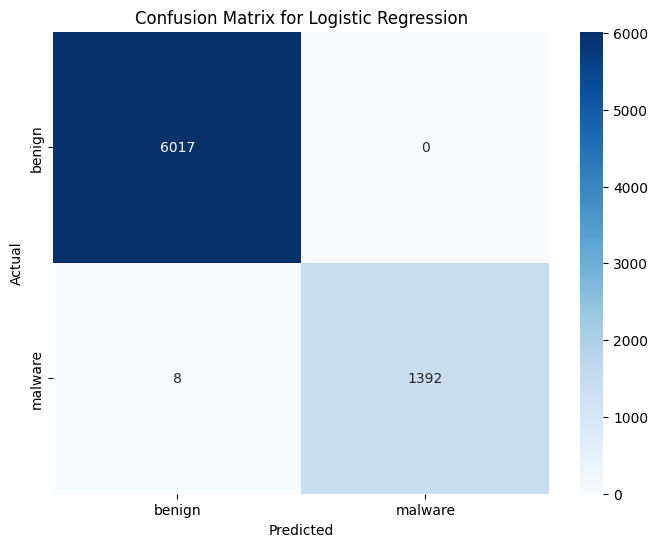

In [14]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get class labels from the LabelEncoder
class_labels = label_encoder.classes_

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()